## 1. Load dan Eksplorasi Data

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('./dataset/voice.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Cek informasi dataset
print('=== Distribusi Label ===')
print(df['label'].value_counts())
print('\n=== Info Dataset ===')
print(df.info())
print('\n=== Statistik Deskriptif ===')
print(df.describe())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
meanfreq    0
sd          0
median      0
Q25         0
Q75         0
IQR         0
skew        0
kurt        0
sp.ent      0
sfm         0
mode        0
centroid    0
meanfun     0
minfun      0
maxfun      0
meandom     0
mindom      0
maxdom      0
dfrange     0
modindx     0
label       0
dtype: int64


## 2. Preprocessing Data

In [4]:
# Encode label: male=1, female=0
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
print('Kelas:', le.classes_)
print('Encoded:', df['label'].value_counts().to_dict())

Kelas: ['female' 'male']
Encoded: {1: 1584, 0: 1584}


In [5]:
# Pisahkan fitur dan label
fitur_kolom = df.columns.drop('label').tolist()
print('Semua fitur yang tersedia:')
for i, col in enumerate(fitur_kolom):
    print(f'  {i+1}. {col}')

Semua fitur yang tersedia:
  1. meanfreq
  2. sd
  3. median
  4. Q25
  5. Q75
  6. IQR
  7. skew
  8. kurt
  9. sp.ent
  10. sfm
  11. mode
  12. centroid
  13. meanfun
  14. minfun
  15. maxfun
  16. meandom
  17. mindom
  18. maxdom
  19. dfrange
  20. modindx


## 3. Percobaan Fitur - Mencari Fitur Optimal

Kita akan melakukan beberapa percobaan:
1. Menggunakan **semua fitur** (baseline)
2. Menggunakan **korelasi tinggi** terhadap label
3. Menggunakan **feature importance** dari model sederhana
4. Mencoba kombinasi fitur tertentu

=== Korelasi Fitur terhadap Label (absolut) ===
meanfun     0.833921
IQR         0.618916
Q25         0.511455
sp.ent      0.490552
sd          0.479539
sfm         0.357499
centroid    0.337415
meanfreq    0.337415
median      0.283919
maxdom      0.195657
mindom      0.194974
dfrange     0.192213
meandom     0.191067
mode        0.171775
maxfun      0.166461
minfun      0.136692
kurt        0.087195
Q75         0.066906
skew        0.036627
modindx     0.030801
Name: label, dtype: float64


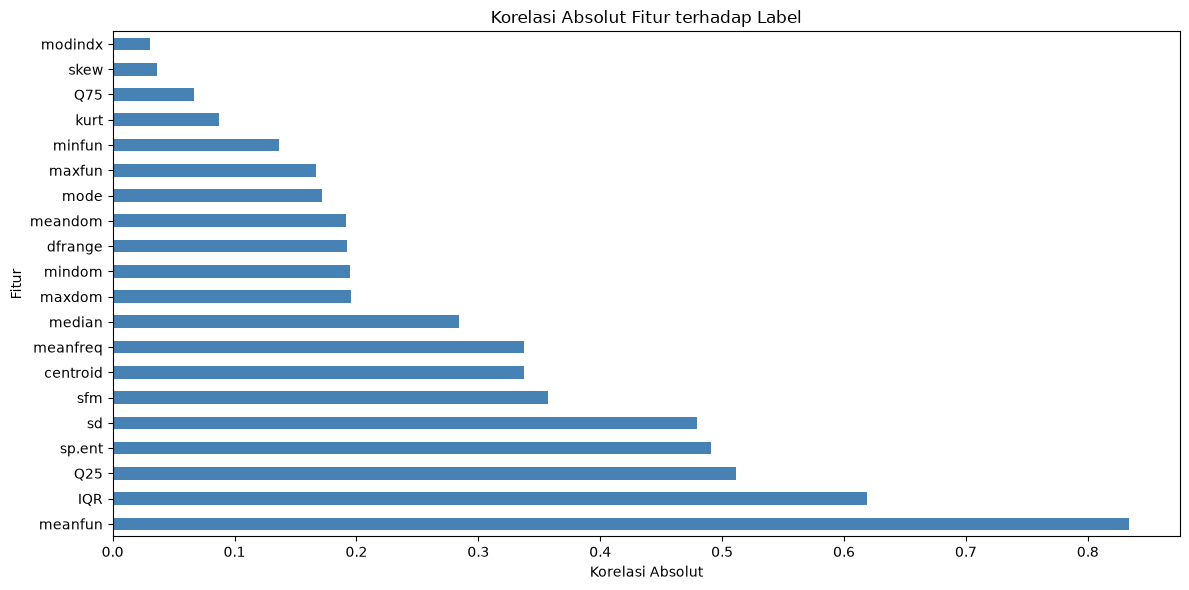

In [6]:
# Analisis korelasi fitur terhadap label
korelasi = df.corr(numeric_only=True)['label'].drop('label').abs().sort_values(ascending=False)
print('=== Korelasi Fitur terhadap Label (absolut) ===')
print(korelasi)

# Visualisasi korelasi
plt.figure(figsize=(12, 6))
korelasi.plot(kind='barh', color='steelblue')
plt.title('Korelasi Absolut Fitur terhadap Label')
plt.xlabel('Korelasi Absolut')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [7]:
# Fungsi helper untuk evaluasi model kNN
def evaluasi_knn(X_data, y_data, fitur_nama, k=5):
    """
    Fungsi untuk mengevaluasi model kNN dengan fitur tertentu.
    Mengembalikan akurasi training dan testing.
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42
    )
    
    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Training dan prediksi
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    
    return train_acc, test_acc

In [8]:
# ===== PERCOBAAN FITUR =====
y = df['label'].values

# Percobaan 1: Semua fitur (20 fitur)
fitur_semua = fitur_kolom
X_semua = df[fitur_semua].values
train_acc1, test_acc1 = evaluasi_knn(X_semua, y, 'Semua Fitur')

# Percobaan 2: Top 10 fitur berkorelasi tinggi
fitur_top10 = korelasi.head(10).index.tolist()
X_top10 = df[fitur_top10].values
train_acc2, test_acc2 = evaluasi_knn(X_top10, y, 'Top 10 Korelasi')

# Percobaan 3: Top 5 fitur berkorelasi tinggi
fitur_top5 = korelasi.head(5).index.tolist()
X_top5 = df[fitur_top5].values
train_acc3, test_acc3 = evaluasi_knn(X_top5, y, 'Top 5 Korelasi')

# Percobaan 4: Top 8 fitur berkorelasi tinggi
fitur_top8 = korelasi.head(8).index.tolist()
X_top8 = df[fitur_top8].values
train_acc4, test_acc4 = evaluasi_knn(X_top8, y, 'Top 8 Korelasi')

# Percobaan 5: Top 15 fitur berkorelasi tinggi
fitur_top15 = korelasi.head(15).index.tolist()
X_top15 = df[fitur_top15].values
train_acc5, test_acc5 = evaluasi_knn(X_top15, y, 'Top 15 Korelasi')

# Tampilkan hasil perbandingan
print('=' * 65)
print(f'{"Percobaan":<25} {"Jumlah Fitur":<15} {"Train Acc":<12} {"Test Acc"}')
print('=' * 65)
print(f'{"Semua Fitur":<25} {len(fitur_semua):<15} {train_acc1:.4f}       {test_acc1:.4f}')
print(f'{"Top 15 Korelasi":<25} {len(fitur_top15):<15} {train_acc5:.4f}       {test_acc5:.4f}')
print(f'{"Top 10 Korelasi":<25} {len(fitur_top10):<15} {train_acc2:.4f}       {test_acc2:.4f}')
print(f'{"Top 8 Korelasi":<25} {len(fitur_top8):<15} {train_acc4:.4f}       {test_acc4:.4f}')
print(f'{"Top 5 Korelasi":<25} {len(fitur_top5):<15} {train_acc3:.4f}       {test_acc3:.4f}')
print('=' * 65)

Percobaan                 Jumlah Fitur    Train Acc    Test Acc
Semua Fitur               20              0.9826       0.9811
Top 15 Korelasi           15              0.9838       0.9748
Top 10 Korelasi           10              0.9866       0.9858
Top 8 Korelasi            8               0.9866       0.9842
Top 5 Korelasi            5               0.9862       0.9795


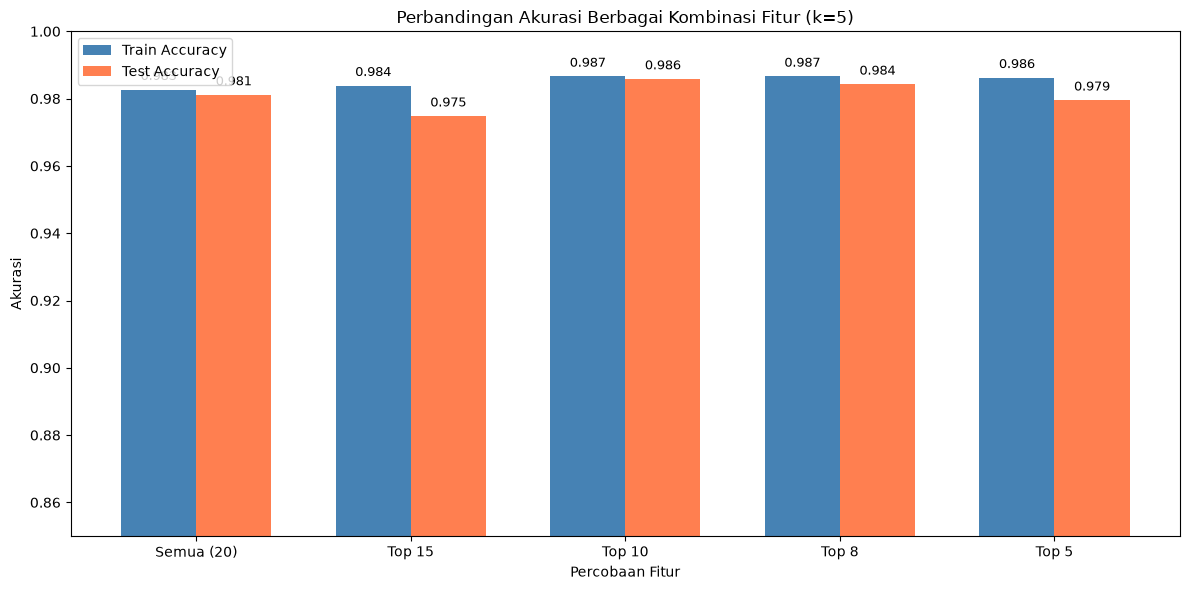

In [9]:
# Visualisasi perbandingan percobaan fitur
percobaan = ['Semua (20)', 'Top 15', 'Top 10', 'Top 8', 'Top 5']
train_accs = [train_acc1, train_acc5, train_acc2, train_acc4, train_acc3]
test_accs = [test_acc1, test_acc5, test_acc2, test_acc4, test_acc3]

x_pos = np.arange(len(percobaan))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_pos - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x_pos + width/2, test_accs, width, label='Test Accuracy', color='coral')

ax.set_xlabel('Percobaan Fitur')
ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi Berbagai Kombinasi Fitur (k=5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(percobaan)
ax.legend()
ax.set_ylim(0.85, 1.0)

# Tambahkan label nilai
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# Tentukan fitur terbaik berdasarkan hasil percobaan
# Kita pilih kombinasi dengan test accuracy terbaik
hasil = {
    'Semua (20)': (test_acc1, fitur_semua),
    'Top 15': (test_acc5, fitur_top15),
    'Top 10': (test_acc2, fitur_top10),
    'Top 8': (test_acc4, fitur_top8),
    'Top 5': (test_acc3, fitur_top5),
}

terbaik = max(hasil.items(), key=lambda x: x[1][0])
fitur_terbaik = terbaik[1][1]

print(f'\nKombinasi fitur terbaik: {terbaik[0]} (Akurasi Test: {terbaik[1][0]:.4f})')
print(f'\nFitur yang digunakan:')
for i, f in enumerate(fitur_terbaik):
    print(f'  {i+1}. {f}')


Kombinasi fitur terbaik: Top 10 (Akurasi Test: 0.9858)

Fitur yang digunakan:
  1. meanfun
  2. IQR
  3. Q25
  4. sp.ent
  5. sd
  6. sfm
  7. centroid
  8. meanfreq
  9. median
  10. maxdom


## 4. Mencari Nilai k Terbaik

Menggunakan fitur terbaik yang sudah dipilih, kita akan mencoba berbagai nilai k untuk menemukan yang optimal.

In [15]:
# Siapkan data dengan fitur terbaik
X_best = df[fitur_terbaik].values
y_best = df['label'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y_best, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Uji berbagai nilai k (1 sampai 20)
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Tampilkan hasil
print(f'{"k":<5} {"Train Acc":<12} {"Test Acc"}')
print('=' * 20)
for k, tr, te in zip(k_range, train_scores, test_scores):
    marker = ' <-- terbaik' if te == max(test_scores) else ''
    print(f'{k:<5} {tr:.4f}       {te:.4f}{marker}')

k     Train Acc    Test Acc
1     1.0000       0.9685
2     0.9913       0.9732
3     0.9909       0.9826
4     0.9886       0.9811
5     0.9866       0.9858
6     0.9862       0.9842
7     0.9826       0.9842
8     0.9838       0.9842
9     0.9830       0.9874 <-- terbaik
10    0.9834       0.9858
11    0.9815       0.9842
12    0.9811       0.9842
13    0.9783       0.9842
14    0.9787       0.9842
15    0.9763       0.9858
16    0.9755       0.9811
17    0.9736       0.9795
18    0.9747       0.9811
19    0.9736       0.9826
20    0.9740       0.9826


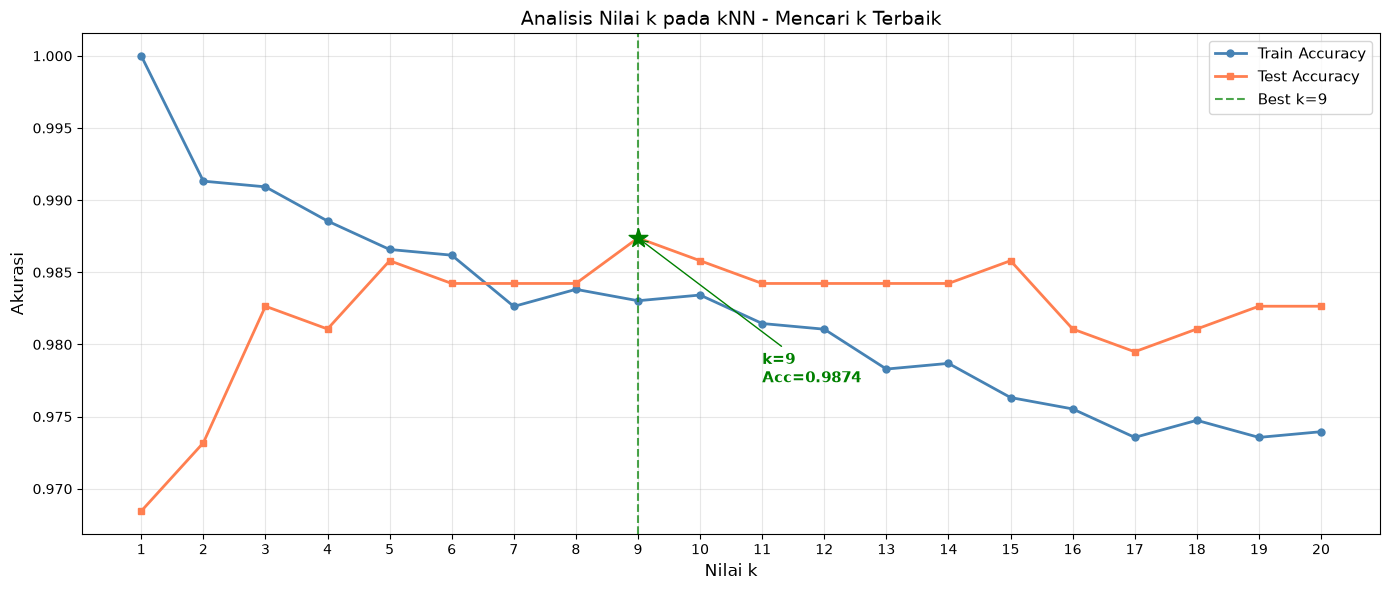


Nilai k terbaik: 9 dengan Test Accuracy: 0.9874


In [16]:
# Grafik Analisis Nilai k
plt.figure(figsize=(14, 6))

plt.plot(k_range, train_scores, 'o-', color='steelblue', label='Train Accuracy', linewidth=2, markersize=5)
plt.plot(k_range, test_scores, 's-', color='coral', label='Test Accuracy', linewidth=2, markersize=5)

# Tandai k terbaik
best_k = list(k_range)[np.argmax(test_scores)]
best_score = max(test_scores)
plt.axvline(x=best_k, color='green', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
plt.scatter([best_k], [best_score], color='green', s=200, zorder=5, marker='*')
plt.annotate(f'k={best_k}\nAcc={best_score:.4f}',
             xy=(best_k, best_score),
             xytext=(best_k + 2, best_score - 0.01),
             fontsize=11, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green'))

plt.xlabel('Nilai k', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.title('Analisis Nilai k pada kNN - Mencari k Terbaik', fontsize=14)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nNilai k terbaik: {best_k} dengan Test Accuracy: {best_score:.4f}')

## 5. Model Final dengan k Terbaik

In [13]:
# Model final
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

# Evaluasi
print('=== Hasil Evaluasi Model Final ===')
print(f'Nilai k: {best_k}')
print(f'Jumlah fitur: {len(fitur_terbaik)}')
print(f'Akurasi Training: {accuracy_score(y_train, knn_final.predict(X_train_scaled)):.4f}')
print(f'Akurasi Testing : {accuracy_score(y_test, y_pred):.4f}')
print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'=== Confusion Matrix ===')
print(confusion_matrix(y_test, y_pred))

=== Hasil Evaluasi Model Final ===
Nilai k: 9
Jumlah fitur: 10
Akurasi Training: 0.9830
Akurasi Testing : 0.9874

=== Classification Report ===
              precision    recall  f1-score   support

      female       0.98      0.99      0.99       297
        male       0.99      0.99      0.99       337

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634

=== Confusion Matrix ===
[[294   3]
 [  5 332]]


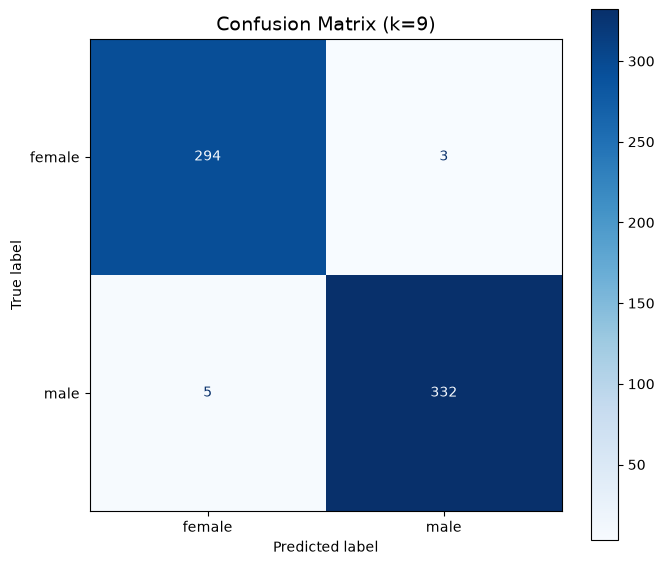

In [14]:
# Visualisasi Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    knn_final, X_test_scaled, y_test,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix (k={best_k})', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Kesimpulan

### Fitur Optimal
Berdasarkan percobaan di atas, fitur-fitur yang dipilih berdasarkan korelasi tertinggi terhadap label memberikan hasil terbaik. Fitur dengan korelasi rendah cenderung menambahkan noise yang dapat menurunkan performa model.

### Nilai k Terbaik
Dari grafik analisis nilai k:
- **k yang terlalu kecil** (misalnya k=1) menyebabkan **overfitting** — akurasi training sangat tinggi tetapi akurasi testing lebih rendah karena model terlalu sensitif terhadap noise.
- **k yang terlalu besar** menyebabkan **underfitting** — model terlalu general dan tidak dapat menangkap pola penting dalam data.
- **k terbaik** memberikan keseimbangan antara bias dan variance, menghasilkan akurasi testing tertinggi.